<a href="https://colab.research.google.com/github/watermelon-3012/flickr8k-image-captioning/blob/main/image_captioning_with_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [2]:
import torch
import random
import numpy as np

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

#**Data Preprocessing**

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Path to dataset files: /kaggle/input/flickr8k


In [4]:
import pandas as pd

df = pd.read_csv(f"{path}/captions.txt")

In [5]:
df

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
...,...,...
40450,997722733_0cb5439472.jpg,A man in a pink shirt climbs a rock face
40451,997722733_0cb5439472.jpg,A man is rock climbing high in the air .
40452,997722733_0cb5439472.jpg,A person in a red shirt climbing up a rock fac...
40453,997722733_0cb5439472.jpg,A rock climber in a red shirt .


## Caption preprocessing

In [6]:
import re

def preprocess_caption(caption):
    caption = caption.lower()
    caption = re.sub(r'[^a-z ]', '', caption)   # remove punctuation/numbers
    caption = re.sub(r'\s+', ' ', caption)      # remove extra space
    caption = '<sos> ' + caption + ' <eos>'     # add special tokens
    return caption.strip()

In [7]:
# Preprocess text

df["processed_caption"] = df["caption"].apply(preprocess_caption)

## Vocabulary building

In [8]:
from collections import Counter

all_captions = df['processed_caption'].tolist()
tokens = [word for cap in all_captions for word in cap.split()]

counter = Counter(tokens)

# remove rare words (threshold = 10)
min_freq = 10
vocab = [word for word, freq in counter.items() if freq >= min_freq]

# special tokens
vocab = ['<sos>', '<eos>', '<pad>', '<unk>'] + vocab

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(vocab)

In [9]:
# Convert caption to vocab index

def encode_caption(caption):
    return [
        word2idx.get(word, word2idx['<unk>'])
        for word in caption.split()
    ]

In [10]:
df['encoded'] = df['processed_caption'].apply(encode_caption)

In [11]:
max_seq_len = max(len(seq) for seq in df['encoded'])
print(max_seq_len)

37


## Images processing

In [12]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    # Data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Build Dataset Object and split dataset

In [13]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class FlickrDataset(Dataset):
    def __init__(self, caption_df, image_folder, transform):
        self.caption_df = caption_df
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.caption_df)

    def __getitem__(self, idx):
        row = self.caption_df.iloc[idx]

        img_path = os.path.join(self.image_folder, row['image'])
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        caption = torch.tensor(row['encoded'])

        return image, caption

In [14]:
from torch.nn.utils.rnn import pad_sequence

# Pad sequences
def collate_fn(batch):
    images, captions = zip(*batch)

    images = torch.stack(images)

    captions = pad_sequence(
        captions,
        batch_first=True,
        padding_value=word2idx['<pad>']
    )

    return images, captions

In [15]:
from sklearn.model_selection import train_test_split

# Split train,val,test set by images (since an image has many captions)
unique_images = df['image'].unique()

# train - 80%, val/test - 10%
train_imgs, temp_imgs = train_test_split(
    unique_images, test_size=0.2, random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs, test_size=0.5, random_state=42
)

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)
test_df  = df[df['image'].isin(test_imgs)].reset_index(drop=True)

In [16]:
image_folder = "/kaggle/input/flickr8k/Images"

train_dataset = FlickrDataset(train_df, image_folder, transform)
val_dataset   = FlickrDataset(val_df, image_folder, transform)
test_dataset  = FlickrDataset(test_df, image_folder, transform)

In [17]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 32360
Val dataset size: 4045
Test dataset size: 4050


In [18]:
from torch.utils.data import DataLoader

def create_DataLoader(dataset, batch_size = 32, shuffle = True):
    loader = DataLoader(
      dataset,
      batch_size = batch_size,
      shuffle = shuffle,
      num_workers = 2,
      collate_fn = collate_fn,
    )
    return loader

In [19]:
train_loader = create_DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = create_DataLoader(val_dataset, batch_size = 32, shuffle = True)
test_loader = create_DataLoader(test_dataset, batch_size = 32, shuffle = False)

# **Functions for training and saving training result**

In [19]:
def train_model_2phase(model, train_loader, val_loader,
                         vocab,
                         train_losses, train_accuracies,
                         val_losses, val_accuracies,
                         total_epochs,
                         freeze_epochs=10,
                         unfreeze_step=3,
                         device="cuda"):

    import torch
    import torch.nn as nn

    model.to(device)

    # Loss with label smoothing
    criterion = nn.CrossEntropyLoss(
        ignore_index=word2idx["<pad>"],
        label_smoothing=0.1
    )

    # Phase 1: Freeze encoder
    print("Freezing encoder...")
    for param in model.encoder.parameters():
        param.requires_grad = False

    optimizer = torch.optim.AdamW([
        {"params": model.decoder.parameters(), "lr": 1e-4},
        {"params": model.output_layer.parameters(), "lr": 1e-4},
    ], weight_decay=1e-4)

    best_val_loss = float('inf')
    patience = 8
    wait = 0

    # Track gradual unfreezing
    total_blocks = 12

    for epoch in range(total_epochs):

        # Phase 2: Gradual Unfreezing
        if epoch >= freeze_epochs:

            # how many blocks to unfreeze
            num_unfreeze = min((epoch - freeze_epochs) // unfreeze_step + 1, total_blocks)

            print(f"\nGradual unfreezing: last {num_unfreeze} blocks\n")

            for name, param in model.encoder.named_parameters():
                param.requires_grad = False

                # Unfreeze last blocks
                for i in range(total_blocks - num_unfreeze, total_blocks):
                    if f"blocks.{i}" in name:
                        param.requires_grad = True

            # Rebuild optimizer
            optimizer = torch.optim.AdamW([
                {"params": model.encoder.parameters(), "lr": 1e-6},
                {"params": model.decoder.parameters(), "lr": 1e-4},
                {"params": model.output_layer.parameters(), "lr": 1e-4},
            ], weight_decay=1e-4)

        # ===== TRAIN =====
        model.train()
        train_loss_total = 0
        train_tokens = 0
        train_correct = 0

        for images, latex in train_loader:
            images = images.to(device)
            latex = latex.to(device).long()

            decoder_in = latex[:, :-1]
            target = latex[:, 1:]

            optimizer.zero_grad()

            output = model(images, decoder_in)

            B, T, V = output.shape

            loss = criterion(
                output.reshape(B * T, V),
                target.reshape(B * T)
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            preds = output.argmax(dim=-1)
            mask = target != word2idx["<pad>"]

            train_correct += ((preds == target) & mask).sum().item()
            train_tokens += mask.sum().item()
            train_loss_total += loss.item() * mask.sum().item()

        train_loss = train_loss_total / train_tokens
        train_acc = train_correct / train_tokens

        # ===== VALIDATION =====
        model.eval()
        val_loss_total = 0
        val_tokens = 0
        val_correct = 0

        with torch.no_grad():
            for images, latex in val_loader:
                images = images.to(device)
                latex = latex.to(device).long()

                decoder_in = latex[:, :-1]
                target = latex[:, 1:]

                output = model(images, decoder_in)

                B, T, V = output.shape

                loss = criterion(
                    output.reshape(B * T, V),
                    target.reshape(B * T)
                )

                preds = output.argmax(dim=-1)
                mask = target != word2idx["<pad>"]

                val_correct += ((preds == target) & mask).sum().item()
                val_tokens += mask.sum().item()
                val_loss_total += loss.item() * mask.sum().item()

        val_loss = val_loss_total / val_tokens
        val_acc = val_correct / val_tokens

        # ===== SAVE METRICS =====
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{total_epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

        # ===== EARLY STOPPING =====
        if val_loss < best_val_loss - 1e-3:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            wait += 1

        if wait >= patience:
            print("Early stopping triggered")
            break

In [54]:
import matplotlib.pyplot as plt

def plot_training_curves(model_name, train_losses, val_losses, train_acc, val_acc):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14,5))

    # ---- LOSS ----
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    # ---- ACCURACY ----
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)

    # ---- GLOBAL TITLE ----
    plt.suptitle(f"[{model_name}] \n Training and Validation Performance Curves", fontsize=16)

    # Adjust layout so the suptitle doesn’t overlap
    plt.tight_layout(rect=[0, 0, 1, 1])

    plt.show()

# **Model: ViT**

## Pretrained ViT Encoder

In [20]:
import timm
import torch.nn as nn

class ViTEncoder(nn.Module):
    def __init__(self, model_name="cct_7_3x1_32", pretrained=True):
        super().__init__()
        self.model = timm.create_model("vit_tiny_patch16_224", pretrained = pretrained, num_classes=0)

        # remove classifier head
        self.model.reset_classifier(0)

    def forward(self, x):
        x = self.model.forward_features(x)  # (B, N, D)
        return x

## Transformer Decoder

In [21]:
class Sequence_Embedding(nn.Module):
  def __init__(self, max_seq_length: int, vocab_size: int, embed_dim: int):
    '''
      Class tỏch.nn.Embedding:
      num_embeddings (int) – size of the dictionary of embeddings
      embedding_dim (int) – the size of each embedding vector
    '''
    super().__init__()
    self.pos_embedding = nn.Embedding(num_embeddings = max_seq_length,
                                      embedding_dim = embed_dim)
    self.token_embedding = nn.Embedding(num_embeddings = vocab_size,
                                        embedding_dim = embed_dim)
  def forward(self, sequence: torch.tensor):
    # Input sequence's shape: (batch_size, seq_len)
    batch_size, seq_len = sequence.shape

    # Token embedding
    token_embed = self.token_embedding(sequence)         # (batch_size, seq_len, embed_dim)

    # Position embedding
    position = torch.arange(seq_len, device = sequence.device)  # (seq_len,)
    position = position.unsqueeze(0)                     # (1, seq_len)
    pos_embed = self.pos_embedding(position)             # (1, seq_len, embed_dim)

    return token_embed + pos_embed

In [22]:
class Causal_Multihead_Attention(nn.Module):
  def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
    super().__init__()
    assert embed_dim % num_heads == 0 # Make sure that embedding dim is divisable to number of heads

    self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim,)
    self.multi_head_attention = nn.MultiheadAttention(embed_dim = embed_dim,
                                                      num_heads = num_heads,
                                                      dropout = dropout,
                                                      batch_first = True,)
    self.dropout = nn.Dropout(p = dropout)
  def forward(self, x: torch.tensor, token_ids: torch.tensor, pad_id = word2idx['<pad>']):
    # x: (batch_size, seq_len, embed_dim
    x_norm = self.layer_norm(x)
    max_seq_len = x.shape[1]

    # Create mask
    key_padding_mask = (token_ids == pad_id)    # shape (batch_size, tokens), dtype bool
    causal_mask = torch.triu(torch.ones(max_seq_len, max_seq_len, device=x.device), diagonal=1).bool()
    output, attn_weights = self.multi_head_attention(query = x_norm,
                                                     key = x_norm,
                                                     value = x_norm,
                                                     attn_mask = causal_mask,
                                                     key_padding_mask = key_padding_mask)
    output = self.dropout(output)
    return x + output, attn_weights

In [23]:
class Cross_Attention(nn.Module):
  def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
    super().__init__()
    assert embed_dim % num_heads == 0 # Make sure that embedding dim is divisable to number of heads

    self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)
    self.multi_head_attention = nn.MultiheadAttention(embed_dim = embed_dim,
                                                      num_heads = num_heads,
                                                      dropout = dropout,
                                                      batch_first = True)
    self.dropout = nn.Dropout(p = dropout)
  def forward(self, x: torch.tensor, context: torch.tensor):
    # context vector is from the ViT encoder
    x_norm = self.layer_norm(x)
    output, attn_weights = self.multi_head_attention(query = x_norm,
                                                     key = context,
                                                     value = context,
                                                     is_causal = False)
    output = self.dropout(output)
    return x + output, attn_weights

In [24]:
class FeedForward(nn.Module):
  def __init__(self, embed_dim: int, hidden_dim: int, dropout: float = 0.1):
    super().__init__()
    self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)
    self.feed_forward = nn.Sequential(
        nn.Linear(in_features = embed_dim,
                  out_features = hidden_dim),
        nn.GELU(),
        nn.Dropout(p = dropout),
        nn.Linear(in_features = hidden_dim,
                  out_features = embed_dim),
        nn.Dropout(p = dropout)
    )
  def forward(self, x: torch.tensor):
    x_norm = self.layer_norm(x)
    return x + self.feed_forward(x_norm)

In [25]:
class TransformerDecoderLayer(nn.Module):
  def __init__(self, embed_dim: int, num_heads: int, ffw_dim: int, max_seq_len, vocab_size, dropout: float = 0.1):
    super().__init__()
    self.causal_attention = Causal_Multihead_Attention(embed_dim, num_heads, dropout)
    self.cross_attention = Cross_Attention(embed_dim, num_heads, dropout)
    self.feed_forward = FeedForward(embed_dim, ffw_dim, dropout)
  def forward(self, x: torch.tensor, token_ids: torch.tensor, context: torch.tensor):
    x, causal_attn_weights = self.causal_attention(x, token_ids)
    x, cross_attn_weights = self.cross_attention(x, context)
    x = self.feed_forward(x)
    return x, causal_attn_weights, cross_attn_weights

In [26]:
class TransformerDecoder(nn.Module):
  def __init__(self, max_seq_len, vocab_size, embed_dim: int, num_layers: int = 12, num_heads: int = 2, ffw_dim: int = 512, dropout: float = 0.1):
    super().__init__()
    self.seq_embedding = Sequence_Embedding(max_seq_len, vocab_size, embed_dim)
    self.layers = nn.ModuleList([
        TransformerDecoderLayer(embed_dim, num_heads, ffw_dim, max_seq_len, vocab_size, dropout)
        for _ in range(num_layers)
    ])

  def forward(self, token_ids: torch.tensor, context: torch.tensor):
    causal_attn_weights = None
    cross_attn_weights = None
    x = self.seq_embedding(token_ids)
    for layer in self.layers:
      x, causal_attn_weights, cross_attn_weights = layer(x, token_ids, context)
    return x, causal_attn_weights, cross_attn_weights

## Caption Model

In [27]:
import torch
import torch.nn as nn

class CaptionModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = ViTEncoder()
        self.embed_dim = self.encoder.model.embed_dim
        self.decoder = TransformerDecoder(
            max_seq_len=max_seq_len,
            vocab_size=vocab_size,
            embed_dim=self.embed_dim,
            dropout=0.2
        )

        # Project encoder output if needed
        self.encoder_proj = nn.Linear(self.embed_dim, self.embed_dim)

        # Final vocab projection
        self.output_layer = nn.Linear(self.embed_dim, vocab_size)

    def forward(self, images, token_ids):
        # Encoder
        features = self.encoder(images)              # (B, N, encoder_dim)
        features = self.encoder_proj(features)       # (B, N, embed_dim)

        # Decoder
        x, _, _ = self.decoder(token_ids, features)  # (B, seq_len, embed_dim)

        # Output logits
        logits = self.output_layer(x)                # (B, seq_len, vocab_size)

        return logits

# **Model Training**

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [30]:
model = CaptionModel(vocab_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [31]:
model.embed_dim

192

In [32]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

train_model_2phase(
    model,
    train_loader,
    val_loader,
    vocab,
    train_losses,
    train_accuracies,
    val_losses,
    val_accuracies,
    total_epochs=50,
    freeze_epochs=5,
    unfreeze_step=1,
    device=device
)

Freezing encoder...
Epoch 1/50
Train Loss: 4.6810 | Train Acc: 0.2811
Val   Loss: 4.1410 | Val   Acc: 0.3391
Epoch 2/50
Train Loss: 4.0453 | Train Acc: 0.3376
Val   Loss: 3.9055 | Val   Acc: 0.3602
Epoch 3/50
Train Loss: 3.8383 | Train Acc: 0.3597
Val   Loss: 3.7877 | Val   Acc: 0.3737
Epoch 4/50
Train Loss: 3.7123 | Train Acc: 0.3741
Val   Loss: 3.7136 | Val   Acc: 0.3829
Epoch 5/50
Train Loss: 3.6177 | Train Acc: 0.3865
Val   Loss: 3.6661 | Val   Acc: 0.3919

Gradual unfreezing: last 1 blocks

Epoch 6/50
Train Loss: 3.5526 | Train Acc: 0.3970
Val   Loss: 3.6288 | Val   Acc: 0.3976

Gradual unfreezing: last 2 blocks

Epoch 7/50
Train Loss: 3.4927 | Train Acc: 0.4048
Val   Loss: 3.5976 | Val   Acc: 0.3987

Gradual unfreezing: last 3 blocks

Epoch 8/50
Train Loss: 3.4423 | Train Acc: 0.4121
Val   Loss: 3.5750 | Val   Acc: 0.4053

Gradual unfreezing: last 4 blocks

Epoch 9/50
Train Loss: 3.3968 | Train Acc: 0.4195
Val   Loss: 3.5624 | Val   Acc: 0.4050

Gradual unfreezing: last 5 blocks


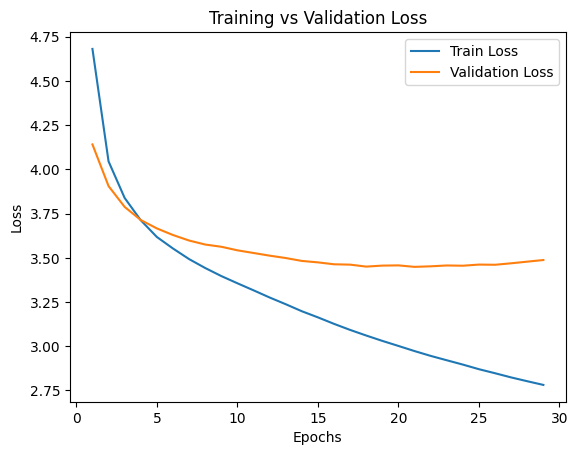

In [47]:
# Store the provided losses and plot them using matplotlib

import matplotlib.pyplot as plt

# Training and validation losses extracted from the logs
train_losses = [
    4.6810, 4.0453, 3.8383, 3.7123, 3.6177,
    3.5526, 3.4927, 3.4423, 3.3968, 3.3560,
    3.3162, 3.2756, 3.2376, 3.1979, 3.1632,
    3.1265, 3.0922, 3.0605, 3.0302, 3.0016,
    2.9726, 2.9454, 2.9207, 2.8962, 2.8701,
    2.8473, 2.8236, 2.8021, 2.7812
]

val_losses = [
    4.1410, 3.9055, 3.7877, 3.7136, 3.6661,
    3.6288, 3.5976, 3.5750, 3.5624, 3.5423,
    3.5272, 3.5121, 3.4987, 3.4823, 3.4741,
    3.4633, 3.4613, 3.4502, 3.4558, 3.4571,
    3.4487, 3.4518, 3.4566, 3.4552, 3.4616,
    3.4606, 3.4689, 3.4782, 3.4874
]

epochs = range(1, len(train_losses) + 1)

# Plot
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [33]:
# Save model if not early stopping
torch.save(model.state_dict(), "/content/drive/MyDrive/Flickr_image_captioning/best_model.pth")

# **Mdel testing**

## Decode text

In [28]:
idx2word = {idx: word for word, idx in word2idx.items()}

In [29]:
import torch
import torch.nn.functional as F

def beam_search(model, images, sos_id, eos_id, pad_id,
                max_seq_len, beam_size=5, length_norm=True):

    model.eval()
    device = next(model.parameters()).device
    images = images.to(device)

    batch_size = images.size(0)

    # Encode ONCE
    with torch.no_grad():
        encoder_out = model.encoder(images)          # (B, N, D)
        encoder_out = model.encoder_proj(encoder_out)

    # Expand encoder output for beams
    encoder_out = encoder_out.unsqueeze(1).repeat(1, beam_size, 1, 1)
    encoder_out = encoder_out.view(batch_size * beam_size, *encoder_out.shape[2:])

    # Initialize sequences
    seqs = torch.full((batch_size * beam_size, 1), sos_id, dtype=torch.long, device=device)
    scores = torch.zeros(batch_size * beam_size, device=device)
    finished = torch.zeros(batch_size * beam_size, dtype=torch.bool, device=device)

    for t in range(max_seq_len):

        logits = model.decoder(seqs, encoder_out)[0]   # (B*beam, T, D)
        logits = model.output_layer(logits[:, -1, :])  # (B*beam, vocab)

        log_probs = F.log_softmax(logits, dim=-1)

        # Mask finished beams
        log_probs[finished] = -1e9
        log_probs[finished, eos_id] = 0

        # Reshape
        scores_ = scores.view(batch_size, beam_size, 1)
        log_probs = log_probs.view(batch_size, beam_size, -1)

        total_scores = scores_ + log_probs
        total_scores = total_scores.view(batch_size, -1)

        top_scores, top_ids = torch.topk(total_scores, beam_size, dim=1)

        vocab_size = log_probs.size(-1)

        beam_ids = top_ids // vocab_size
        token_ids = top_ids % vocab_size

        # beam re-indexing
        offset = (torch.arange(batch_size, device=device) * beam_size).unsqueeze(1)
        beam_ids = (beam_ids + offset).view(-1)
        token_ids = token_ids.view(-1)

        # Update sequences
        seqs = torch.cat([seqs[beam_ids], token_ids.unsqueeze(1)], dim=1)

        scores = top_scores.view(-1)
        finished = finished[beam_ids] | (token_ids == eos_id)

        if finished.view(batch_size, beam_size).all():
            break

    # Length normalization
    if length_norm:
        lengths = (seqs != pad_id).sum(dim=1)
        scores = scores / lengths.clamp(min=1)

    # Select best beams
    scores = scores.view(batch_size, beam_size)
    seqs = seqs.view(batch_size, beam_size, -1)

    best_ids = torch.argmax(scores, dim=1)
    best_seqs = seqs[torch.arange(batch_size), best_ids]

    # Remove special tokens
    results = []
    for seq in best_seqs.tolist():
        if seq[0] == sos_id:
            seq = seq[1:]
        if eos_id in seq:
            seq = seq[:seq.index(eos_id)]
        results.append(seq)

    return results

In [30]:
def decode_text(token_ids_batch, idx2word):
    """
    Decode a batch of token IDs into tokens and strings.

    Args:
          token_ids_batch: list of lists OR 1D list of token IDs

    Returns:
          decoded_tokens_list: list of list of tokens
          decoded_texts: list of strings
    """
    if isinstance(token_ids_batch[0], int):
        token_ids_batch = [token_ids_batch]

    decoded_tokens = []
    decoded_texts = []

    for token_ids in token_ids_batch:
        tokens = []

        for idx in token_ids:
            token = idx2word.get(idx, '<unk>')

            if token in ['<sos>', '<eos>', '<pad>']:
                continue

            tokens.append(token)

        decoded_tokens.append(tokens)
        decoded_texts.append(' '.join(tokens))

    return decoded_tokens, decoded_texts

In [31]:
def evaluate_model(model, test_loader, max_seq_len, beam_size=5):

    model.eval()
    device = next(model.parameters()).device

    true_sequences_tokens = []
    true_sequences_text = []

    predicted_sequences_tokens = []
    predicted_sequences_text = []

    with torch.no_grad():
        for images, true_ids in test_loader:

            images = images.to(device)

            # Ground truth
            true_tokens_batch, true_text_batch = decode_text(true_ids.tolist(), idx2word)

            true_sequences_tokens.extend(true_tokens_batch)
            true_sequences_text.extend(true_text_batch)

            # Predictions
            pred_ids = beam_search(
                model,
                images,
                sos_id=word2idx['<sos>'],
                eos_id=word2idx['<eos>'],
                pad_id=word2idx['<pad>'],
                max_seq_len=max_seq_len,
                beam_size=beam_size
            )

            pred_tokens_batch, pred_text_batch = decode_text(pred_ids, idx2word)

            predicted_sequences_tokens.extend(pred_tokens_batch)
            predicted_sequences_text.extend(pred_text_batch)

    return true_sequences_tokens, true_sequences_text, predicted_sequences_tokens, predicted_sequences_text

In [32]:
model = CaptionModel(vocab_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/Flickr_image_captioning/best_model.pth",
    map_location=device
))

<All keys matched successfully>

In [34]:
import collections
import numpy as np

def bleu1_multi_ref(pred, refs):

    if len(pred) == 0:
        return 0.0

    pred_counts = collections.Counter(pred)

    # 🔥 take MAX match across all references
    max_matches = {}

    for ref in refs:
        ref_counts = collections.Counter(ref)

        for word in pred_counts:
            match = min(pred_counts[word], ref_counts[word])
            max_matches[word] = max(max_matches.get(word, 0), match)

    match_sum = sum(max_matches.values())
    total = sum(pred_counts.values())

    precision = match_sum / total if total > 0 else 0.0

    # brevity penalty (use closest reference length)
    ref_lens = [len(r) for r in refs]
    closest_ref_len = min(ref_lens, key=lambda x: abs(x - len(pred)))

    if len(pred) < closest_ref_len:
        bp = np.exp(1 - closest_ref_len / len(pred))
    else:
        bp = 1.0

    return bp * precision

In [35]:
from collections import defaultdict

image_to_captions = defaultdict(list)

for _, row in df.iterrows():
    image_to_captions[row['image']].append(row['encoded'])

In [36]:
ground_truth = {}

for img, captions in image_to_captions.items():
    tokens, _ = decode_text(captions, idx2word)
    ground_truth[img] = tokens   # list of token lists

In [37]:
class FlickrImageDataset(Dataset):
    def __init__(self, image_names, image_folder, transform):
        self.image_names = image_names
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_folder, img_name)

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        return image, img_name

In [38]:
unique_images = list(image_to_captions.keys())

test_dataset = FlickrImageDataset(unique_images, image_folder, transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
predictions = {}

model.eval()
with torch.no_grad():
    for images, img_names in test_loader:

        images = images.to(device)

        pred_ids = beam_search(
            model,
            images,
            sos_id=word2idx['<sos>'],
            eos_id=word2idx['<eos>'],
            pad_id=word2idx['<pad>'],
            max_seq_len=max_seq_len,
            beam_size=1
        )

        pred_tokens, _ = decode_text(pred_ids, idx2word)

        for name, tokens in zip(img_names, pred_tokens):
            predictions[name] = tokens

In [40]:
scores = []

for img_name in predictions:
    pred = predictions[img_name]
    refs = ground_truth[img_name]

    score = bleu1_multi_ref(pred, refs)
    scores.append(score)

bleu1 = np.mean(scores)

print("BLEU-1:", bleu1)

BLEU-1: 0.6901501327263139


In [41]:
import random

def print_samples(predictions, ground_truth, num_samples=5):

    image_names = list(predictions.keys())
    sampled = random.sample(image_names, num_samples)

    for i, img in enumerate(sampled):
        print(f"\n===== Sample {i+1} =====")

        # Prediction
        pred = predictions[img]
        print("Pred :", " ".join(pred))

        # Ground truth (show 2–3 references)
        refs = ground_truth[img]
        print("GT   :")
        for r in refs[:3]:
            print("      -", " ".join(r))

In [42]:
print_samples(predictions, ground_truth)


===== Sample 1 =====
Pred : a hockey goalie in a red outfit is <unk> the goal
GT   :
      - a goalie tries to block the puck in a hockey game
      - a hockey goalie stops the puck
      - people playing hockey

===== Sample 2 =====
Pred : a white dog wearing a red collar is playing with a brown dog
GT   :
      - a white dog wearing a christmas <unk> headband plays with a brown dog in the grass among some stuffed animals
      - a white dog wearing <unk> ears is next to a brown dog
      - a white dog with fake <unk> on its head and a brown dog play together outdoors

===== Sample 3 =====
Pred : a man is standing on top of a mountain
GT   :
      - a man sits on a rock
      - a man sitting on a cliff in the mountains
      - a man wearing a blue shirt crouches on a rocky cliff

===== Sample 4 =====
Pred : a hockey player in red is <unk> the puck as the referee looks on
GT   :
      - a goalie is covering his net while two other hockey players chase after the hockey puck
      - a g

In [43]:
import json

def save_results_json(predictions, ground_truth, file_path):

    data = []

    for img in predictions:
        entry = {
            "image": img,
            "prediction": predictions[img],
            "ground_truth": ground_truth[img]   # list of references
        }
        data.append(entry)

    with open(file_path, "w") as f:
        json.dump(data, f, indent=4)

In [44]:
save_results_json(
    predictions,
    ground_truth,
    "/content/drive/MyDrive/Flickr_image_captioning/test_results.json"
)

In [45]:
def save_results_txt(predictions, ground_truth, file_path):

    with open(file_path, "w") as f:
        for img in predictions:

            pred = " ".join(predictions[img])
            refs = [" ".join(r) for r in ground_truth[img]]

            f.write(f"Image: {img}\n")
            f.write(f"Pred : {pred}\n")
            f.write("GT   :\n")

            for r in refs:
                f.write(f"  - {r}\n")

            f.write("\n" + "="*50 + "\n\n")

In [46]:
save_results_txt(
    predictions,
    ground_truth,
    "/content/drive/MyDrive/Flickr_image_captioning/results.txt"
)